<a href="https://colab.research.google.com/github/purnikaah/Human-Activity-Recognition/blob/main/AI_NN_week2_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import cv2
import glob
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
from sklearn.preprocessing import LabelEncoder

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

plt.style.use('ggplot')
sns.set_style("whitegrid")
%matplotlib inline

print("Libraries imported successfully.")
print("OpenCV version:", cv2.__version__)


Libraries imported successfully.
OpenCV version: 4.13.0


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving val.csv to val (1).csv
Saving train.csv to train (1).csv
Saving test.csv to test (1).csv


In [ ]:
ZIP_NAME = list(uploaded.keys())[0]
print("Uploaded:", ZIP_NAME, f"({len(uploaded[ZIP_NAME]) / 1e6:.1f} MB)")


Uploaded: val (1).csv (0.1 MB)


In [ ]:
df = pd.read_csv("val.csv", sep=";")
df.head()


,"clip_name,clip_path,label"
0,"v_Swing_g22_c05,/val/Swing/v_Swing_g22_c05.avi..."
1,"v_Swing_g25_c02,/val/Swing/v_Swing_g25_c02.avi..."
2,"v_Swing_g06_c07,/val/Swing/v_Swing_g06_c07.avi..."
3,"v_Swing_g03_c02,/val/Swing/v_Swing_g03_c02.avi..."
4,"v_Swing_g02_c05,/val/Swing/v_Swing_g02_c05.avi..."


In [ ]:
print("Shape:", df.shape)
df.head()

Shape: (1673, 1)


,"clip_name,clip_path,label"
0,"v_Swing_g22_c05,/val/Swing/v_Swing_g22_c05.avi..."
1,"v_Swing_g25_c02,/val/Swing/v_Swing_g25_c02.avi..."
2,"v_Swing_g06_c07,/val/Swing/v_Swing_g06_c07.avi..."
3,"v_Swing_g03_c02,/val/Swing/v_Swing_g03_c02.avi..."
4,"v_Swing_g02_c05,/val/Swing/v_Swing_g02_c05.avi..."


In [ ]:
df.describe()


,"clip_name,clip_path,label"
count,1673
unique,1673
top,"v_Diving_g10_c04,/val/Diving/v_Diving_g10_c04...."
freq,1


In [ ]:
df.describe(include='object')


,"clip_name,clip_path,label"
count,1673
unique,1673
top,"v_Diving_g10_c04,/val/Diving/v_Diving_g10_c04...."
freq,1


In [ ]:
df.isnull().sum()

,0
clip_name,0
clip_path,0
label,0
split,0


In [ ]:
for col in df.select_dtypes(include='object'):
    print(col)
    print((df[col]=='unknown').sum())


clip_name,clip_path,label
0


In [ ]:
duplicates = df.duplicated().sum()
print("Duplicate rows:", duplicates)

df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

Duplicate rows: 13451
Shape after removing duplicates: (13451, 4)


In [ ]:
print("Shape:", df.shape)
print("Number of unique action classes:", df['label'].nunique())
print("Splits available:", df['split'].unique().tolist())
df.groupby('split').size()

Shape: (13451, 4)
Number of unique action classes: 101
Splits available: ['test', 'train', 'val']


,0
split,
test,1723
train,10055
val,1673


Distribution of Target Variable

/tmp/ipykernel_677/1086744865.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.values, y=class_counts.index, palette="viridis")


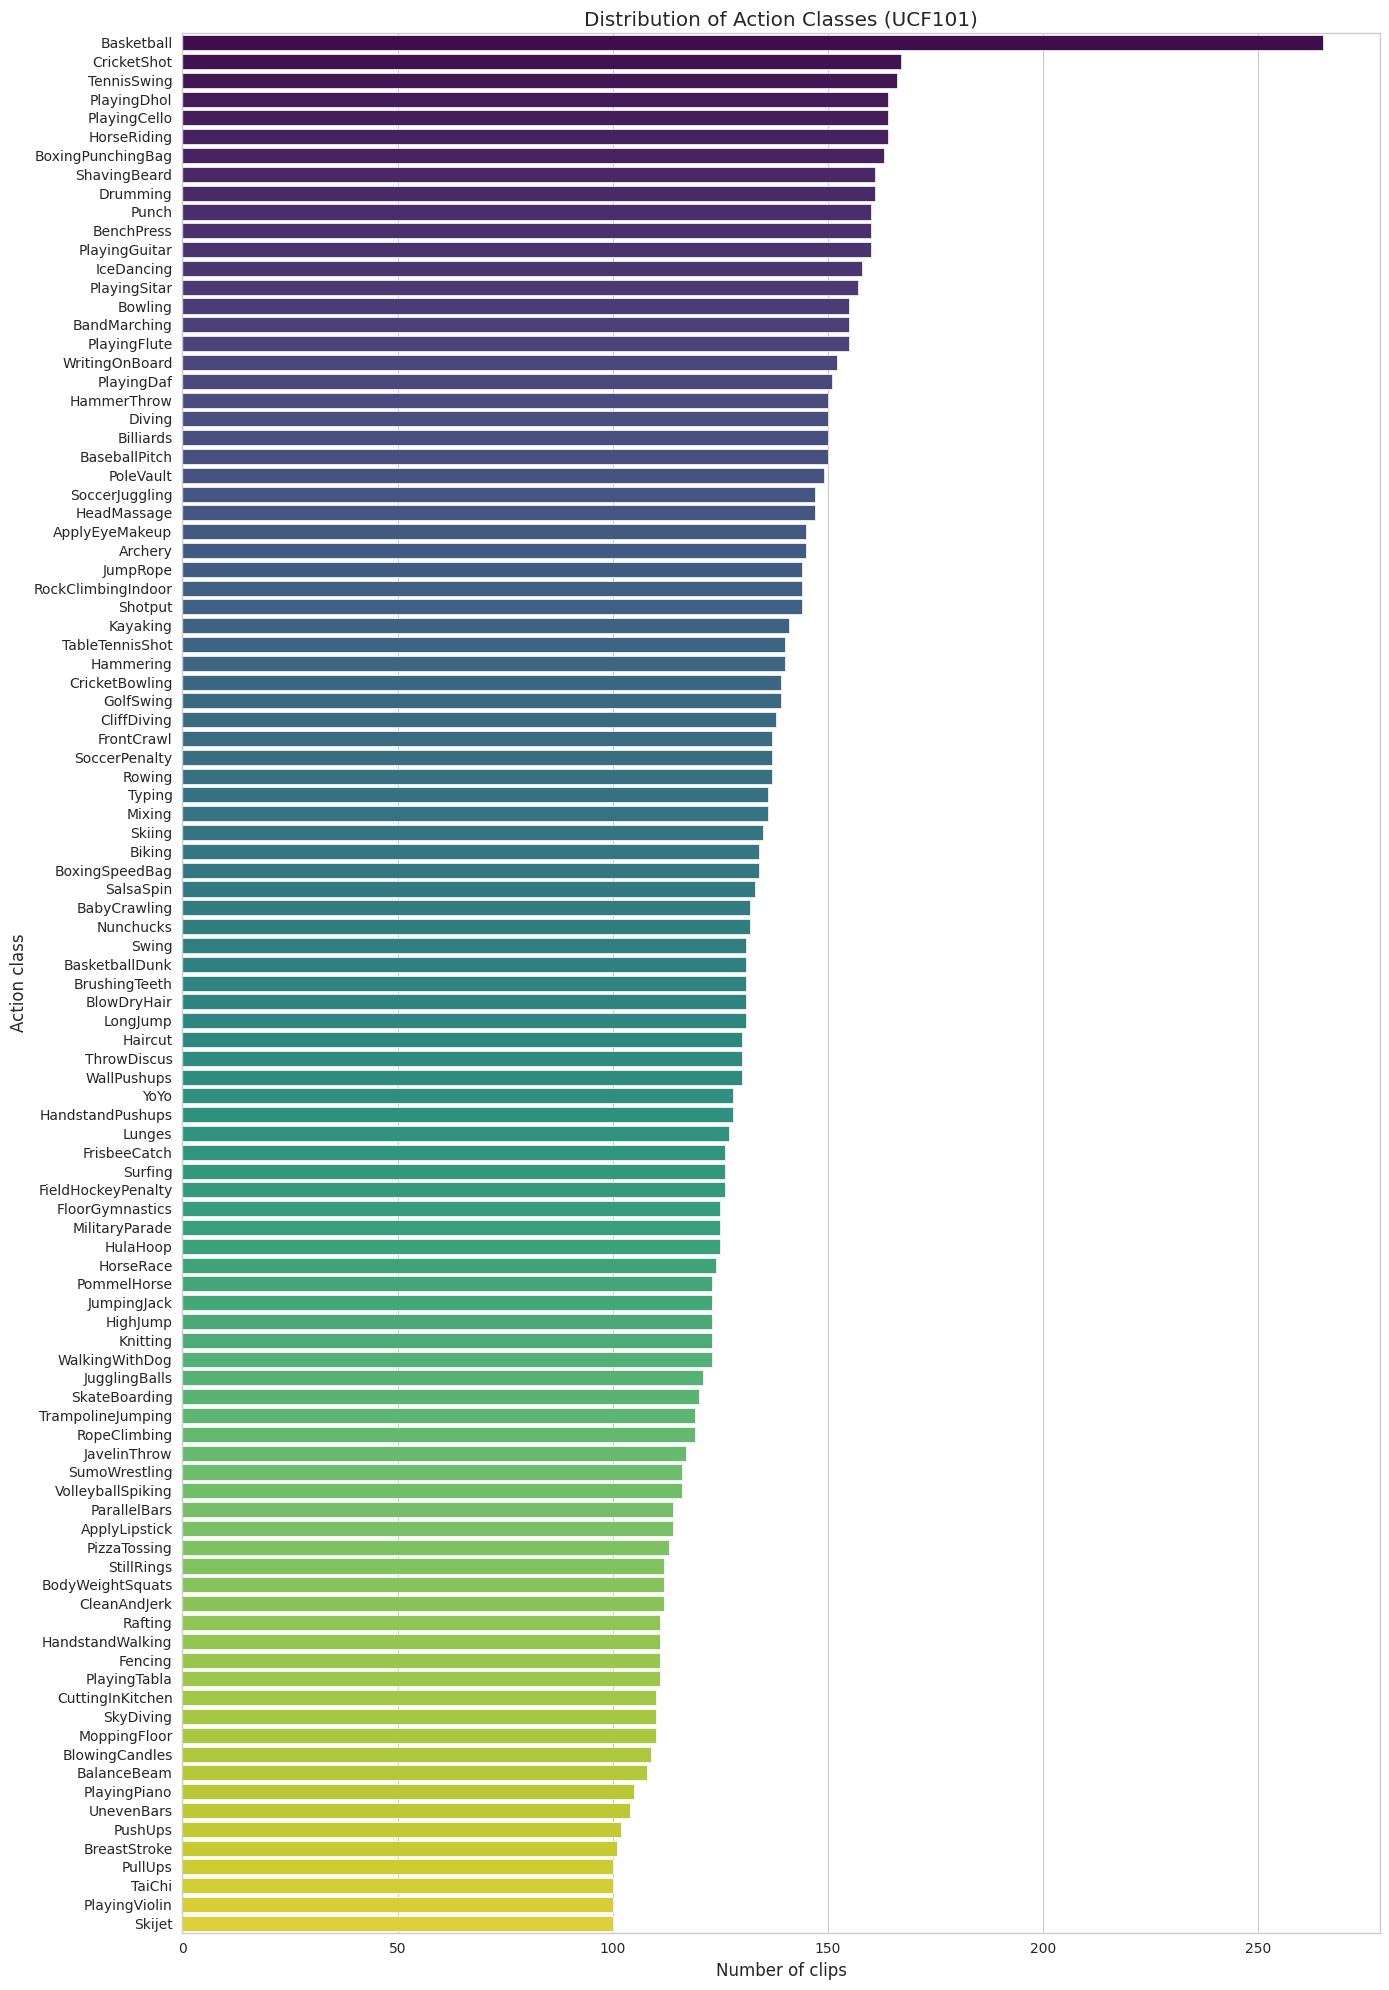

Most common classes:
 label
Basketball      265
CricketShot     167
TennisSwing     166
PlayingDhol     164
PlayingCello    164
Name: count, dtype: int64

Least common classes:
 label
BreastStroke     101
PullUps          100
TaiChi           100
PlayingViolin    100
Skijet           100
Name: count, dtype: int64


In [ ]:
plt.figure(figsize=(14, 20))
class_counts = df['label'].value_counts()
sns.barplot(x=class_counts.values, y=class_counts.index, palette="viridis")
plt.title("Distribution of Action Classes (UCF101)")
plt.xlabel("Number of clips")
plt.ylabel("Action class")
plt.tight_layout()
plt.show()

print("Most common classes:\n", class_counts.head(5))
print("\nLeast common classes:\n", class_counts.tail(5))

Split Distribution

/tmp/ipykernel_677/2514024457.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='split', data=df, order=['train', 'val', 'test'], palette="Set2")


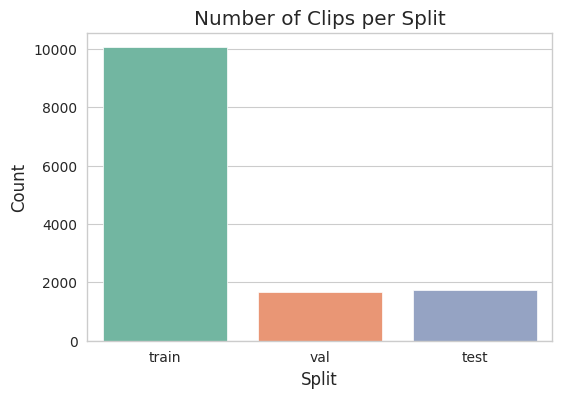

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(x='split', data=df, order=['train', 'val', 'test'], palette="Set2")
plt.title("Number of Clips per Split")
plt.xlabel("Split")
plt.ylabel("Count")
plt.show()

Class Balance Across Splits

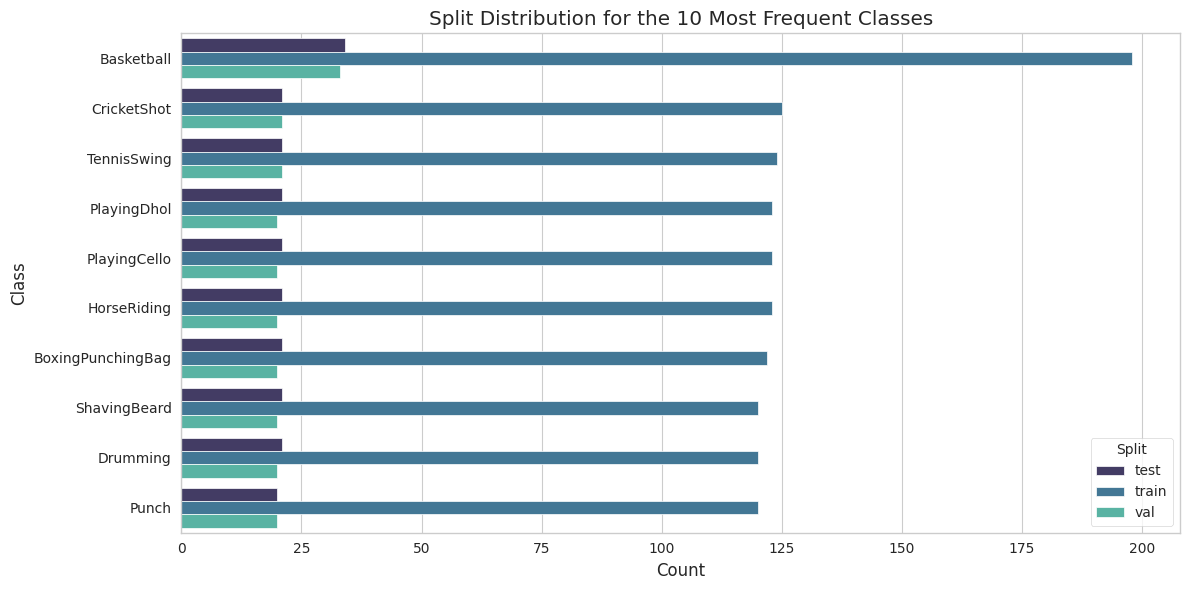

In [ ]:
top_classes = class_counts.head(10).index
subset = df[df['label'].isin(top_classes)]

plt.figure(figsize=(12, 6))
sns.countplot(data=subset, y='label', hue='split', order=top_classes, palette="mako")
plt.title("Split Distribution for the 10 Most Frequent Classes")
plt.xlabel("Count")
plt.ylabel("Class")
plt.legend(title="Split")
plt.tight_layout()
plt.show()

Class Imbalance Check

In [ ]:
print("Clips per class - summary statistics:")
class_counts.describe()

Clips per class - summary statistics:


,count
count,101.000000
mean,133.178218
std,22.595750
min,100.000000
25%,117.000000
50%,131.000000
75%,147.000000
max,265.000000


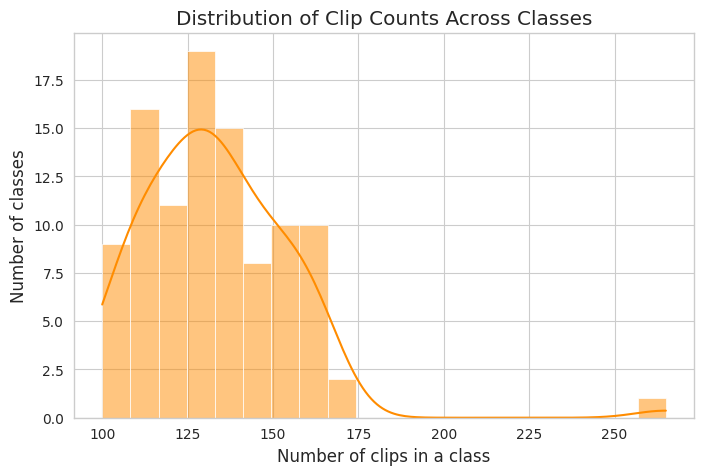

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(class_counts.values, bins=20, kde=True, color="darkorange")
plt.title("Distribution of Clip Counts Across Classes")
plt.xlabel("Number of clips in a class")
plt.ylabel("Number of classes")
plt.show()

Label Encoding

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['label'])

label_map = dict(zip(le.classes_, le.transform(le.classes_)))
print(f"Number of classes: {len(label_map)}")
print("Example mapping:", dict(list(label_map.items())[:5]))
df.head()

Number of classes: 101
Example mapping: {'ApplyEyeMakeup': np.int64(0), 'ApplyLipstick': np.int64(1), 'Archery': np.int64(2), 'BabyCrawling': np.int64(3), 'BalanceBeam': np.int64(4)}


/tmp/ipykernel_677/3079114526.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['label_encoded'] = le.fit_transform(df['label'])


,clip_name,clip_path,label,split,label_encoded
0,v_Swing_g21_c02,/test/Swing/v_Swing_g21_c02.avi,Swing,test,88
1,v_Swing_g21_c06,/test/Swing/v_Swing_g21_c06.avi,Swing,test,88
2,v_Swing_g20_c05,/test/Swing/v_Swing_g20_c05.avi,Swing,test,88
3,v_Swing_g04_c03,/test/Swing/v_Swing_g04_c03.avi,Swing,test,88
4,v_Swing_g19_c03,/test/Swing/v_Swing_g19_c03.avi,Swing,test,88


In [ ]:
import os

video_files = [f for f in uploaded.keys() if f.lower().endswith('.avi')]
print(f"Uploaded {len(video_files)} video files directly.")

VIDEO_DIR = "/content/ucf101_raw_uploads"
os.makedirs(VIDEO_DIR, exist_ok=True)

import shutil
for f in video_files:
    shutil.move(f, os.path.join(VIDEO_DIR, f))

print("Files now in:", VIDEO_DIR)
print("Sample:", os.listdir(VIDEO_DIR)[:5])

Uploaded 108 video files directly.
Files now in: /content/ucf101_raw_uploads
Sample: ['v_ApplyEyeMakeup_g12_c02.avi', 'v_ApplyEyeMakeup_g25_c02.avi', 'v_ApplyEyeMakeup_g21_c04.avi', 'v_ApplyEyeMakeup_g13_c04.avi', 'v_ApplyEyeMakeup_g09_c04.avi']


In [ ]:
import glob

all_video_files = glob.glob(os.path.join(VIDEO_DIR, "*.avi"))
print(f"Found {len(all_video_files)} video files.")

name_to_path = {os.path.splitext(os.path.basename(p))[0]: p for p in all_video_files}

df['clip_path_local'] = df['clip_name'].map(name_to_path)
df_subset = df[df['clip_path_local'].notna()].reset_index(drop=True)

print(f"Rows in metadata matching an uploaded video: {len(df_subset)}")
df_subset[['clip_name', 'label', 'split', 'clip_path_local']].head()

Found 0 video files.
Rows in metadata matching an uploaded video: 0


/tmp/ipykernel_677/1029429050.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['clip_path_local'] = df['clip_name'].map(name_to_path)


,clip_name,label,split,clip_path_local


In [ ]:
import glob

found_anywhere = glob.glob("/content/**/*.avi", recursive=True)
print(f"Total .avi files found anywhere under /content: {len(found_anywhere)}")
print(found_anywhere[:10])

Total .avi files found anywhere under /content: 252
['/content/v_ApplyEyeMakeup_g12_c02.avi', '/content/v_ApplyEyeMakeup_g25_c02.avi', '/content/v_ApplyEyeMakeup_g12_c05.avi', '/content/v_ApplyEyeMakeup_g03_c05 (1).avi', '/content/v_ApplyEyeMakeup_g21_c04.avi', '/content/v_ApplyEyeMakeup_g13_c04.avi', '/content/v_ApplyEyeMakeup_g25_c07.avi', '/content/v_ApplyEyeMakeup_g09_c04.avi', '/content/v_ApplyEyeMakeup_g11_c02 (1).avi', '/content/v_ApplyEyeMakeup_g01_c01.avi']


In [ ]:
import glob
import os
import re

VIDEO_DIR = "/content"

all_video_files = glob.glob(os.path.join(VIDEO_DIR, "*.avi"))
print(f"Video files found: {len(all_video_files)}")

def clean_name(path):
    """Strip extension and any ' (1)', ' (2)' duplicate-upload suffix."""
    name = os.path.splitext(os.path.basename(path))[0]
    name = re.sub(r"\s*\(\d+\)$", "", name)
    return name

name_to_path = {}
for p in all_video_files:
    key = clean_name(p)
    if key not in name_to_path:
        name_to_path[key] = p

print(f"Unique clip names after de-duplication: {len(name_to_path)}")
print("Sample keys:", list(name_to_path.keys())[:5])

Video files found: 144
Unique clip names after de-duplication: 126
Sample keys: ['v_ApplyEyeMakeup_g12_c02', 'v_ApplyEyeMakeup_g25_c02', 'v_ApplyEyeMakeup_g12_c05', 'v_ApplyEyeMakeup_g03_c05', 'v_ApplyEyeMakeup_g21_c04']


In [ ]:
df_subset = df.copy()
df_subset['clip_path_local'] = df_subset['clip_name'].map(name_to_path)
df_subset = df_subset[df_subset['clip_path_local'].notna()].reset_index(drop=True)

print(f"Rows in metadata matching an uploaded video: {len(df_subset)}")
df_subset[['clip_name', 'label', 'split', 'clip_path_local']].head()

Rows in metadata matching an uploaded video: 126


,clip_name,label,split,clip_path_local
0,v_ApplyEyeMakeup_g06_c04,ApplyEyeMakeup,train,/content/v_ApplyEyeMakeup_g06_c04.avi
1,v_ApplyEyeMakeup_g03_c06,ApplyEyeMakeup,train,/content/v_ApplyEyeMakeup_g03_c06.avi
2,v_ApplyEyeMakeup_g11_c03,ApplyEyeMakeup,train,/content/v_ApplyEyeMakeup_g11_c03.avi
3,v_ApplyEyeMakeup_g15_c03,ApplyEyeMakeup,train,/content/v_ApplyEyeMakeup_g15_c03.avi
4,v_ApplyEyeMakeup_g10_c04,ApplyEyeMakeup,train,/content/v_ApplyEyeMakeup_g10_c04.avi


Corrupt-clip check + video metadata

In [ ]:
import cv2
import numpy as np
import pandas as pd

def get_video_metadata(video_path):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        cap.release()
        return None
    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    duration = frame_count / fps if fps and fps > 0 else np.nan
    cap.release()
    return fps, frame_count, duration, width, height

records, corrupt_videos = [], []
for _, row in df_subset.iterrows():
    meta = get_video_metadata(row['clip_path_local'])
    if meta is None:
        corrupt_videos.append(row['clip_path_local'])
        continue
    fps, frame_count, duration, width, height = meta
    records.append({"label": row['label'], "split": row['split'], "fps": fps,
                     "frame_count": frame_count, "duration_sec": duration,
                     "width": width, "height": height})

meta_df = pd.DataFrame(records)
print(f"Readable clips: {len(meta_df)}  |  Corrupt clips: {len(corrupt_videos)}")
if corrupt_videos:
    print("Examples:", corrupt_videos[:3])
meta_df.describe()

Readable clips: 126  |  Corrupt clips: 0


,fps,frame_count,duration_sec,width,height
count,126.0,126.000000,126.000000,126.0,126.0
mean,25.0,169.420635,6.776825,320.0,240.0
std,0.0,51.397954,2.055918,0.0,0.0
min,25.0,90.000000,3.600000,320.0,240.0
25%,25.0,126.000000,5.040000,320.0,240.0
50%,25.0,165.500000,6.620000,320.0,240.0
75%,25.0,208.000000,8.320000,320.0,240.0
max,25.0,296.000000,11.840000,320.0,240.0


 Duration / FPS

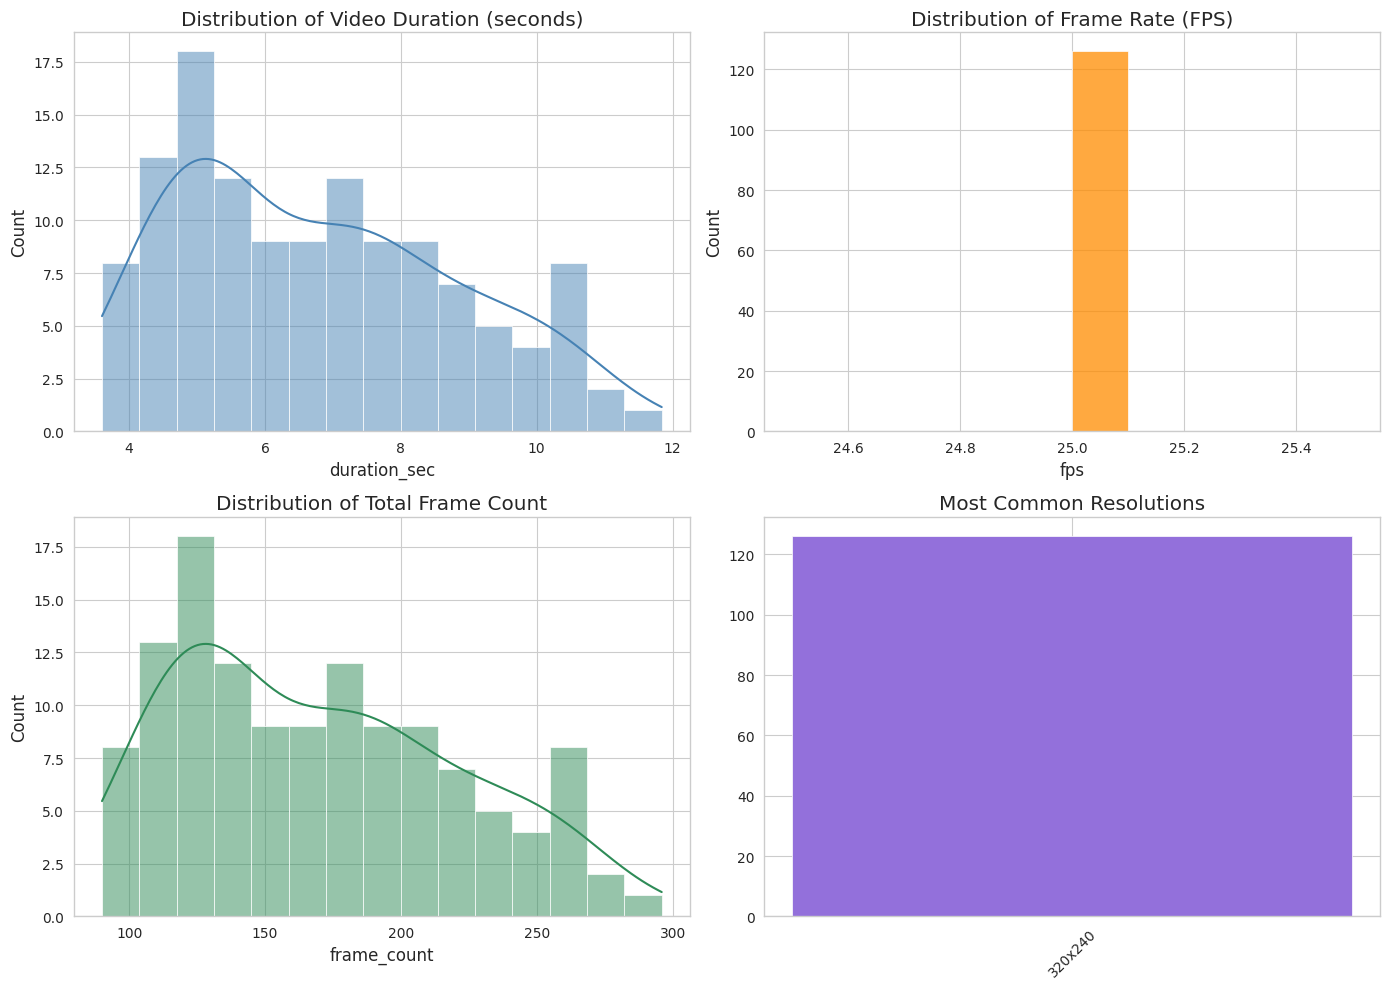

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.histplot(meta_df['duration_sec'].dropna(), bins=15, kde=True, ax=axes[0,0], color="steelblue")
axes[0,0].set_title("Distribution of Video Duration (seconds)")

sns.histplot(meta_df['fps'].dropna(), bins=10, ax=axes[0,1], color="darkorange")
axes[0,1].set_title("Distribution of Frame Rate (FPS)")

sns.histplot(meta_df['frame_count'].dropna(), bins=15, kde=True, ax=axes[1,0], color="seagreen")
axes[1,0].set_title("Distribution of Total Frame Count")

res_counts = meta_df.groupby(['width','height']).size().sort_values(ascending=False)
res_labels = [f"{w}x{h}" for w,h in res_counts.index]
axes[1,1].bar(res_labels[:10], res_counts.values[:10], color="mediumpurple")
axes[1,1].set_title("Most Common Resolutions")
axes[1,1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

Outlier detection

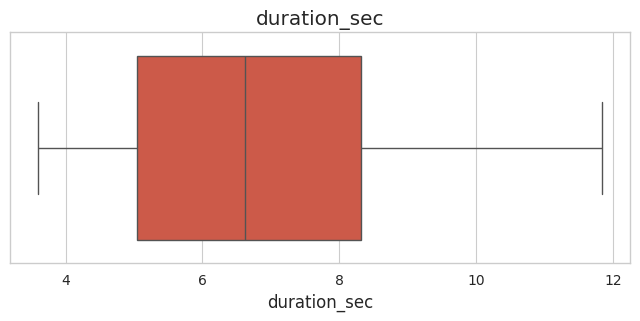

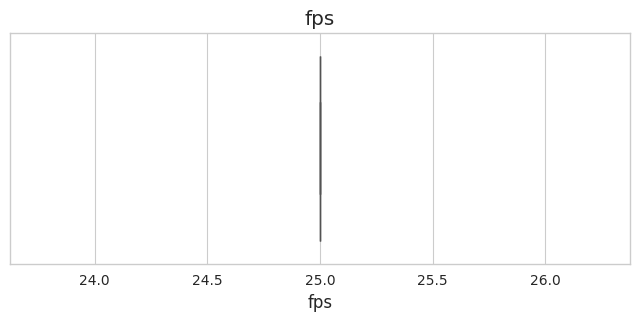

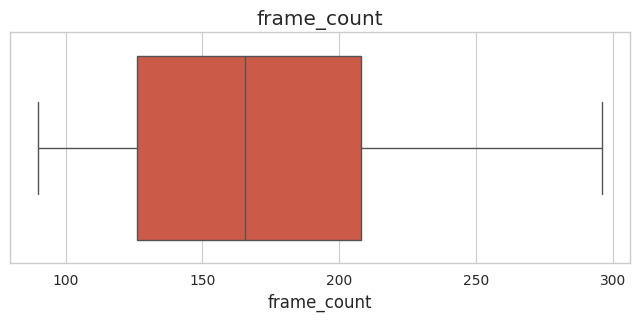

In [ ]:
for col in ['duration_sec', 'fps', 'frame_count']:
    plt.figure(figsize=(8, 3))
    sns.boxplot(x=meta_df[col])
    plt.title(col)
    plt.show()

Sample frames grid

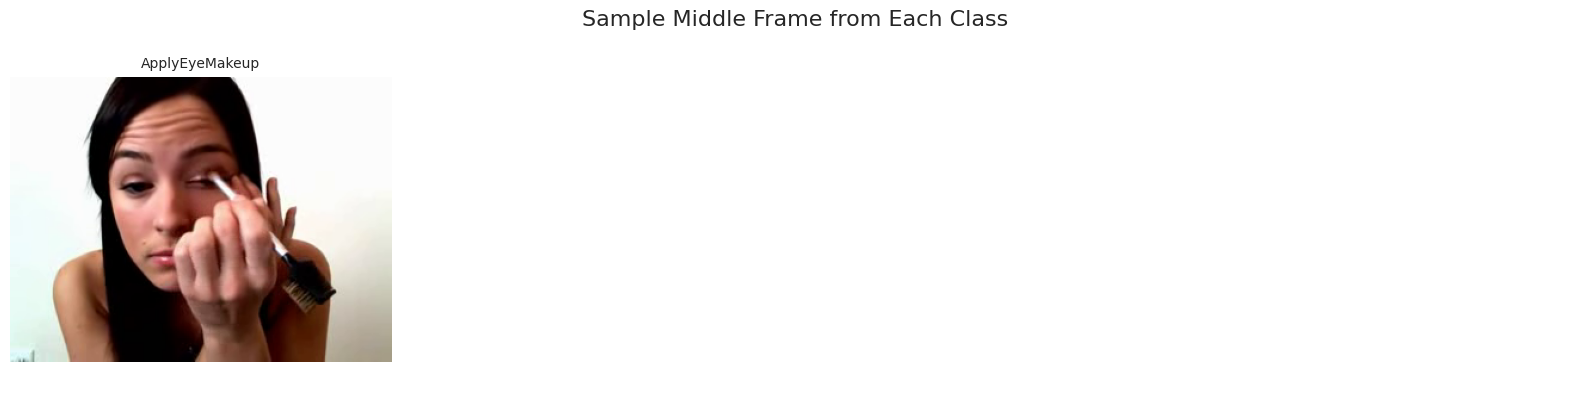

In [ ]:
import random
random.seed(42)

def read_frame(video_path, frame_index=0):
    cap = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    frame_index = min(frame_index, max(total - 1, 0))
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_index)
    ok, frame = cap.read()
    cap.release()
    return cv2.cvtColor(frame, cv2.COLOR_BGR2RGB) if ok else None

classes_available = sorted(df_subset['label'].unique())
n = min(12, len(classes_available))
random_classes = random.sample(classes_available, n)

fig, axes = plt.subplots((n + 3) // 4, 4, figsize=(16, 4 * ((n + 3) // 4)))
axes = axes.flatten()
for ax, cls in zip(axes, random_classes):
    row = df_subset[df_subset['label'] == cls].sample(1, random_state=42).iloc[0]
    cap = cv2.VideoCapture(row['clip_path_local'])
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.release()
    frame = read_frame(row['clip_path_local'], frame_index=total // 2)
    if frame is not None:
        ax.imshow(frame)
    ax.set_title(cls, fontsize=10)
    ax.axis('off')
for ax in axes[len(random_classes):]:
    ax.axis('off')

plt.suptitle("Sample Middle Frame from Each Class", fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
!git clone https://github.com/purnikaah/Human-Activity-Recognition

Cloning into 'Human-Activity-Recognition'...
